<a href="https://colab.research.google.com/github/JabulaniMcineka/MyProjects/blob/main/DeliveryAnalysisProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Delivery Analysis Project

> A data analysis project that ingests delivery data into SQLite, runs SQL-based analysis, and generates visualisation dashboards using Python, Pandas, Matplotlib, and Seaborn.

![Python](https://img.shields.io/badge/Python-3.12-blue)
![Pandas](https://img.shields.io/badge/Pandas-2.2.2-lightblue)
![SQLite](https://img.shields.io/badge/SQLite-Database-lightgrey)
![Seaborn](https://img.shields.io/badge/Seaborn-0.13.2-green)
![Colab](https://img.shields.io/badge/Google-Colab-orange)
![Status](https://img.shields.io/badge/Analysis-✅%20Complete-brightgreen)

---

##  Architecture

```
Synthetic Data (Python)
        │
        ▼
delivery_data.csv
        │
        ▼
SQLite Database (Delivery.db)
        │
        ▼
SQL Analysis Queries (12 queries)
        │
        ▼
Data Quality Checks (9 checks)
        │
        ▼
Visualisation Dashboard (Matplotlib + Seaborn)
```

---

##  Tech Stack

| Tool | Version | Purpose |
|---|---|---|
| Python | 3.12 | Core language |
| Pandas | 2.2.2 | Data loading & transformation |
| SQLite | Built-in | Lightweight database storage |
| Matplotlib | Latest | Chart generation |
| Seaborn | 0.13.2 | Chart styling & colour palettes |
| Google Colab | - | Notebook environment |

---

##  Project Structure

```
delivery-analysis/
├── delivery_data.csv          # Synthetic delivery dataset (250 records)
├── Delivery.db                # SQLite database (auto-generated)
├── delivery_dashboard.png     # Output dashboard image
├── delivery_analysis.ipynb    # Main Colab notebook
└── README.md
```

---

##  Dataset Schema

| Column | Type | Description |
|---|---|---|
| delivery_id | TEXT | Unique delivery identifier |
| city | TEXT | Delivery destination city |
| customer_id | INTEGER | Customer identifier |
| scheduled_datetime | TEXT | Planned delivery datetime |
| delivered_datetime | TEXT | Actual delivery datetime |
| status | TEXT | Delivered / Pending / Failed |
| delay_minutes | INTEGER | Delay in minutes (0 = on time) |
| carrier | TEXT | Carrier name (SwiftX, MegaHaul, SkyDrop) |
| distance_km | INTEGER | Delivery distance in kilometres |
| weight_kg | REAL | Package weight in kilograms |

**Dataset stats:**
- 250 records
- 6 cities: Johannesburg, Cape Town, Durban, Pretoria, Bloemfontein, Gqeberha
- 3 carriers: SwiftX, MegaHaul, SkyDrop
- Date range: January 2025 – June 2025

---

## Getting Started

### Run in Google Colab (Recommended)
1. Open [Google Colab](https://colab.research.google.com)
2. Upload `delivery_analysis.ipynb`
3. Run all cells in order

### Run Locally
```bash
pip install pandas matplotlib seaborn
python delivery_analysis.py
```

---

## 🔄 Notebook Structure

| Cell | Purpose |
|---|---|
| Cell 1 | Install dependencies & imports |
| Cell 2 | Generate synthetic delivery dataset |
| Cell 3 | Load data into SQLite |
| Cell 4 | Data cleaning & quality checks |
| Cell 5 | SQL analysis queries |
| Cell 6 | Visualisation dashboard |
| Cell 7 | Key insights |
| Cell 8 | Final pipeline summary |

---

## SQL Queries Included

| # | Query | Description |
|---|---|---|
| 1 | Total deliveries | Count all records |
| 2 | Deliveries per city | Volume by city |
| 3 | Deliveries by carrier | Volume by carrier |
| 4 | Average delay per carrier | Carrier performance |
| 5 | Delivery status breakdown | Delivered / Pending / Failed |
| 6 | Average distance per city | Distance metrics |
| 7 | Monthly delivery trends | Volume over time |
| 8 | Total weight per carrier | Weight metrics |

---

##  Data Quality Checks

| Check | Expected |
|---|---|
| row_count | > 0 |
| no_null_delivery_id | = 0 nulls |
| no_null_city | = 0 nulls |
| no_null_carrier | = 0 nulls |
| valid_delay_minutes | No negatives |
| valid_distance | No zero/negative |
| valid_weight | No zero/negative |
| unique_delivery_ids | No duplicates |
| valid_status_values | Only Delivered/Pending/Failed |

---

## Dashboard Visualisations

| Chart | Type | Insight |
|---|---|---|
| Total Deliveries per City | Bar chart | Which cities receive most deliveries |
| Average Delay per Carrier | Bar chart | Which carrier is most reliable |
| Monthly Delivery Trends | Line chart | Delivery volume over time |
| Delivery Status Breakdown | Pie chart | Success vs failure rate |
| Package Weight vs Distance | Scatter plot | Relationship between weight and distance |
| Total Weight per Carrier | Horizontal bar | Which carrier handles most weight |

---

##  Author

**Jabulani Mcineka**
-  AWS Certified Cloud Practitioner (2025)
-  AWS Certified Data Engineer – Associate (2025)
-  Postgraduate Diploma in Computer Science — Tshwane University of Technology
-  [LinkedIn](https://www.linkedin.com/in/jabulani-mcineka-941360182)
-  [GitHub](https://github.com/JabulaniMcineka)

---

##  License
MIT


In [2]:
# ============================================================
#   DELIVERY ANALYSIS PROJECT
#   Tools: Python, Pandas, SQLite, Matplotlib, Seaborn
# ============================================================

!pip install pandas matplotlib seaborn -q

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "sans-serif"

print("    All imports successful!")
print(f"   Pandas  : {pd.__version__}")
print(f"   Seaborn : {sns.__version__}")

    All imports successful!
   Pandas  : 2.2.2
   Seaborn : 0.13.2


In [5]:
# ============================================================
#   CELL 2: Generate Synthetic Delivery Data
# ============================================================

random.seed(42)
np.random.seed(42)

cities    = ["Johannesburg", "Cape Town", "Durban", "Pretoria", "Bloemfontein", "Gqeberha"]
carriers  = ["SwiftX", "MegaHaul", "SkyDrop"]
statuses  = ["Delivered", "Delivered", "Delivered", "Pending", "Failed"]  # mostly delivered

def random_datetime(start, end):
    delta = end - start
    return start + timedelta(seconds=random.randint(0, int(delta.total_seconds())))

start_date = datetime(2025, 1, 1)
end_date   = datetime(2025, 6, 30)

records = []
for i in range(250):
    scheduled  = random_datetime(start_date, end_date)
    delay_mins = random.choices([0, 0, 0, random.randint(10, 120)], weights=[60, 20, 10, 10])[0]
    delivered  = scheduled + timedelta(hours=random.randint(4, 30), minutes=delay_mins)
    status     = random.choice(statuses)
    distance   = random.randint(50, 500)
    weight     = round(random.uniform(1.0, 60.0), 1)

    records.append({
        "delivery_id":          f"D{str(i+1).zfill(5)}",
        "city":                 random.choice(cities),
        "customer_id":          random.randint(10000, 20000),
        "scheduled_datetime":   scheduled.strftime("%Y-%m-%d %H:%M:%S"),
        "delivered_datetime":   delivered.strftime("%Y-%m-%d %H:%M:%S"),
        "status":               status,
        "delay_minutes":        delay_mins,
        "carrier":              random.choice(carriers),
        "distance_km":          distance,
        "weight_kg":            weight,
    })

df = pd.DataFrame(records)
df.to_csv("delivery_data.csv", index=False)

print(" Synthetic dataset generated!")
print(f"   Total records : {len(df)}")
print(f"   Cities        : {df['city'].nunique()}")
print(f"   Carriers      : {df['carrier'].nunique()}")
print(f"   Date range    : {df['scheduled_datetime'].min()[:10]} → {df['scheduled_datetime'].max()[:10]}")
print(f"\nSample rows:")
print(df.head(5).to_string(index=False))

 Synthetic dataset generated!
   Total records : 250
   Cities        : 6
   Carriers      : 3
   Date range    : 2025-01-01 → 2025-06-29

Sample rows:
delivery_id         city  customer_id  scheduled_datetime  delivered_datetime    status  delay_minutes  carrier  distance_km  weight_kg
     D00001 Johannesburg        18935 2025-05-05 03:56:41 2025-05-05 15:56:41 Delivered              0   SwiftX          164        9.2
     D00002 Johannesburg        19195 2025-04-25 15:53:40 2025-04-25 21:53:40 Delivered              0   SwiftX          169       30.8
     D00003 Johannesburg        12615 2025-05-20 00:53:35 2025-05-20 17:53:35 Delivered              0  SkyDrop          279       35.8
     D00004 Johannesburg        15881 2025-03-24 01:31:33 2025-03-24 11:31:33 Delivered              0 MegaHaul          102        6.5
     D00005     Pretoria        11291 2025-04-28 05:34:02 2025-04-29 08:34:02   Pending              0  SkyDrop          324        8.4


In [7]:
# ============================================================
#   CELL 3: Load Data into SQLite
# ============================================================

DB_PATH = "Delivery.db"
conn    = sqlite3.connect(DB_PATH)
cur     = conn.cursor()

# Create table
cur.execute("""
    CREATE TABLE IF NOT EXISTS deliveries (
        delivery_id        TEXT PRIMARY KEY,
        city               TEXT,
        customer_id        INTEGER,
        scheduled_datetime TEXT,
        delivered_datetime TEXT,
        status             TEXT,
        delay_minutes      INTEGER,
        carrier            TEXT,
        distance_km        INTEGER,
        weight_kg          REAL
    )
""")
conn.commit()

# Load data
df.to_sql("deliveries", conn, if_exists="replace", index=False)

# Verify
count = conn.execute("SELECT COUNT(*) FROM deliveries").fetchone()[0]
cols  = [r[1] for r in conn.execute("PRAGMA table_info(deliveries)").fetchall()]

print(" Data loaded into SQLite!")
print(f"   Database : {DB_PATH}")
print(f"   Table    : deliveries")
print(f"   Records  : {count}")
print(f"   Columns  : {cols}")

 Data loaded into SQLite!
   Database : Delivery.db
   Table    : deliveries
   Records  : 250
   Columns  : ['delivery_id', 'city', 'customer_id', 'scheduled_datetime', 'delivered_datetime', 'status', 'delay_minutes', 'carrier', 'distance_km', 'weight_kg']


In [9]:
# ============================================================
#   CELL 4: Data Cleaning & Quality Checks
# ============================================================

print("=" * 50)
print("   DATA CLEANING & QUALITY CHECKS")
print("=" * 50)

# ── CLEANING ──
print("\n Cleaning...")

# Fill missing delay_minutes with 0
df["delay_minutes"] = df["delay_minutes"].fillna(0).astype(int)

# Fill missing weight_kg with median
df["weight_kg"] = df["weight_kg"].fillna(df["weight_kg"].median())

# Fill missing distance_km with mean
df["distance_km"] = df["distance_km"].fillna(df["distance_km"].mean()).astype(int)

# Drop rows with missing delivery_id
before = len(df)
df.dropna(subset=["delivery_id"], inplace=True)
dropped = before - len(df)

print(f"    Nulls filled — delay_minutes, weight_kg, distance_km")
print(f"    Dropped {dropped} rows with missing delivery_id")

# Update SQLite with cleaned data
df.to_sql("deliveries", conn, if_exists="replace", index=False)
print(f"    SQLite updated with cleaned data")

# ── QUALITY CHECKS ──
print("\n  Quality Checks...")

checks = [
    ("row_count",              "SELECT COUNT(*) FROM deliveries",                                          lambda r: int(r) > 0),
    ("no_null_delivery_id",    "SELECT COUNT(*) FROM deliveries WHERE delivery_id IS NULL",                lambda r: int(r) == 0),
    ("no_null_city",           "SELECT COUNT(*) FROM deliveries WHERE city IS NULL",                       lambda r: int(r) == 0),
    ("no_null_carrier",        "SELECT COUNT(*) FROM deliveries WHERE carrier IS NULL",                    lambda r: int(r) == 0),
    ("valid_delay_minutes",    "SELECT COUNT(*) FROM deliveries WHERE delay_minutes < 0",                  lambda r: int(r) == 0),
    ("valid_distance",         "SELECT COUNT(*) FROM deliveries WHERE distance_km <= 0",                   lambda r: int(r) == 0),
    ("valid_weight",           "SELECT COUNT(*) FROM deliveries WHERE weight_kg <= 0",                     lambda r: int(r) == 0),
    ("unique_delivery_ids",    "SELECT COUNT(*) - COUNT(DISTINCT delivery_id) FROM deliveries",            lambda r: int(r) == 0),
    ("valid_status_values",    "SELECT COUNT(*) FROM deliveries WHERE status NOT IN ('Delivered','Pending','Failed')", lambda r: int(r) == 0),
]

all_passed = True
for name, sql, check in checks:
    result = conn.execute(sql).fetchone()[0]
    passed = check(result)
    status = " PASS" if passed else " FAIL"
    print(f"   {status} — {name} (result={result})")
    if not passed:
        all_passed = False

print(f"\n{'='*50}")
print(f"   Final Result: {' ALL CHECKS PASSED' if all_passed else '❌ SOME CHECKS FAILED'}")
print(f"{'='*50}")

   DATA CLEANING & QUALITY CHECKS

 Cleaning...
    Nulls filled — delay_minutes, weight_kg, distance_km
    Dropped 0 rows with missing delivery_id
    SQLite updated with cleaned data

  Quality Checks...
    PASS — row_count (result=250)
    PASS — no_null_delivery_id (result=0)
    PASS — no_null_city (result=0)
    PASS — no_null_carrier (result=0)
    PASS — valid_delay_minutes (result=0)
    PASS — valid_distance (result=0)
    PASS — valid_weight (result=0)
    PASS — unique_delivery_ids (result=0)
    PASS — valid_status_values (result=0)

   Final Result:  ALL CHECKS PASSED


In [10]:
# ============================================================
#   CELL 5: SQL Analysis Queries
# ============================================================

print("=" * 50)
print("   SQL ANALYSIS QUERIES")
print("=" * 50)

# 1. Total deliveries
total = conn.execute("SELECT COUNT(*) FROM deliveries").fetchone()[0]
print(f"\n Total Deliveries: {total}")

# 2. Deliveries per city
print("\n  Deliveries per City:")
deliveries_per_city = pd.read_sql("""
    SELECT city, COUNT(*) AS total,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM deliveries), 1) AS percentage
    FROM deliveries
    GROUP BY city
    ORDER BY total DESC
""", conn)
print(deliveries_per_city.to_string(index=False))

# 3. Deliveries by carrier
print("\n Deliveries by Carrier:")
deliveries_by_carrier = pd.read_sql("""
    SELECT carrier, COUNT(*) AS total,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM deliveries), 1) AS percentage
    FROM deliveries
    GROUP BY carrier
    ORDER BY total DESC
""", conn)
print(deliveries_by_carrier.to_string(index=False))

# 4. Average delay per carrier
print("\n  Average Delay per Carrier (minutes):")
carrier_performance = pd.read_sql("""
    SELECT carrier,
           ROUND(AVG(delay_minutes), 1) AS avg_delay,
           MAX(delay_minutes)           AS max_delay,
           SUM(CASE WHEN delay_minutes > 0 THEN 1 ELSE 0 END) AS delayed_count
    FROM deliveries
    GROUP BY carrier
    ORDER BY avg_delay
""", conn)
print(carrier_performance.to_string(index=False))

# 5. Delivery status breakdown
print("\n Delivery Status:")
status_df = pd.read_sql("""
    SELECT status, COUNT(*) AS total,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM deliveries), 1) AS percentage
    FROM deliveries
    GROUP BY status
    ORDER BY total DESC
""", conn)
print(status_df.to_string(index=False))

# 6. Average distance per city
print("\n Average Distance per City (km):")
avg_distance = pd.read_sql("""
    SELECT city,
           ROUND(AVG(distance_km), 1) AS avg_distance,
           MIN(distance_km)           AS min_distance,
           MAX(distance_km)           AS max_distance
    FROM deliveries
    GROUP BY city
    ORDER BY avg_distance DESC
""", conn)
print(avg_distance.to_string(index=False))

# 7. Monthly trends
print("\n Monthly Delivery Trends:")
monthly_trends = pd.read_sql("""
    SELECT strftime('%Y-%m', scheduled_datetime) AS month,
           COUNT(*) AS deliveries,
           ROUND(AVG(delay_minutes), 1) AS avg_delay
    FROM deliveries
    GROUP BY month
    ORDER BY month
""", conn)
print(monthly_trends.to_string(index=False))

# 8. Total weight per carrier
print("\n  Total Weight per Carrier (kg):")
weight_carrier = pd.read_sql("""
    SELECT carrier,
           ROUND(SUM(weight_kg), 1)  AS total_weight,
           ROUND(AVG(weight_kg), 1)  AS avg_weight
    FROM deliveries
    GROUP BY carrier
    ORDER BY total_weight DESC
""", conn)
print(weight_carrier.to_string(index=False))

print("\n All queries complete!")

   SQL ANALYSIS QUERIES

 Total Deliveries: 250

  Deliveries per City:
        city  total  percentage
    Gqeberha     55        22.0
      Durban     48        19.2
Johannesburg     41        16.4
    Pretoria     40        16.0
   Cape Town     37        14.8
Bloemfontein     29        11.6

 Deliveries by Carrier:
 carrier  total  percentage
 SkyDrop     90        36.0
MegaHaul     84        33.6
  SwiftX     76        30.4

  Average Delay per Carrier (minutes):
 carrier  avg_delay  max_delay  delayed_count
 SkyDrop        3.5        110              4
MegaHaul        4.6         97              6
  SwiftX        4.7        102              6

 Delivery Status:
   status  total  percentage
Delivered    140        56.0
  Pending     61        24.4
   Failed     49        19.6

 Average Distance per City (km):
        city  avg_distance  min_distance  max_distance
   Cape Town         311.6            97           498
Bloemfontein         304.6            68           497
    Preto

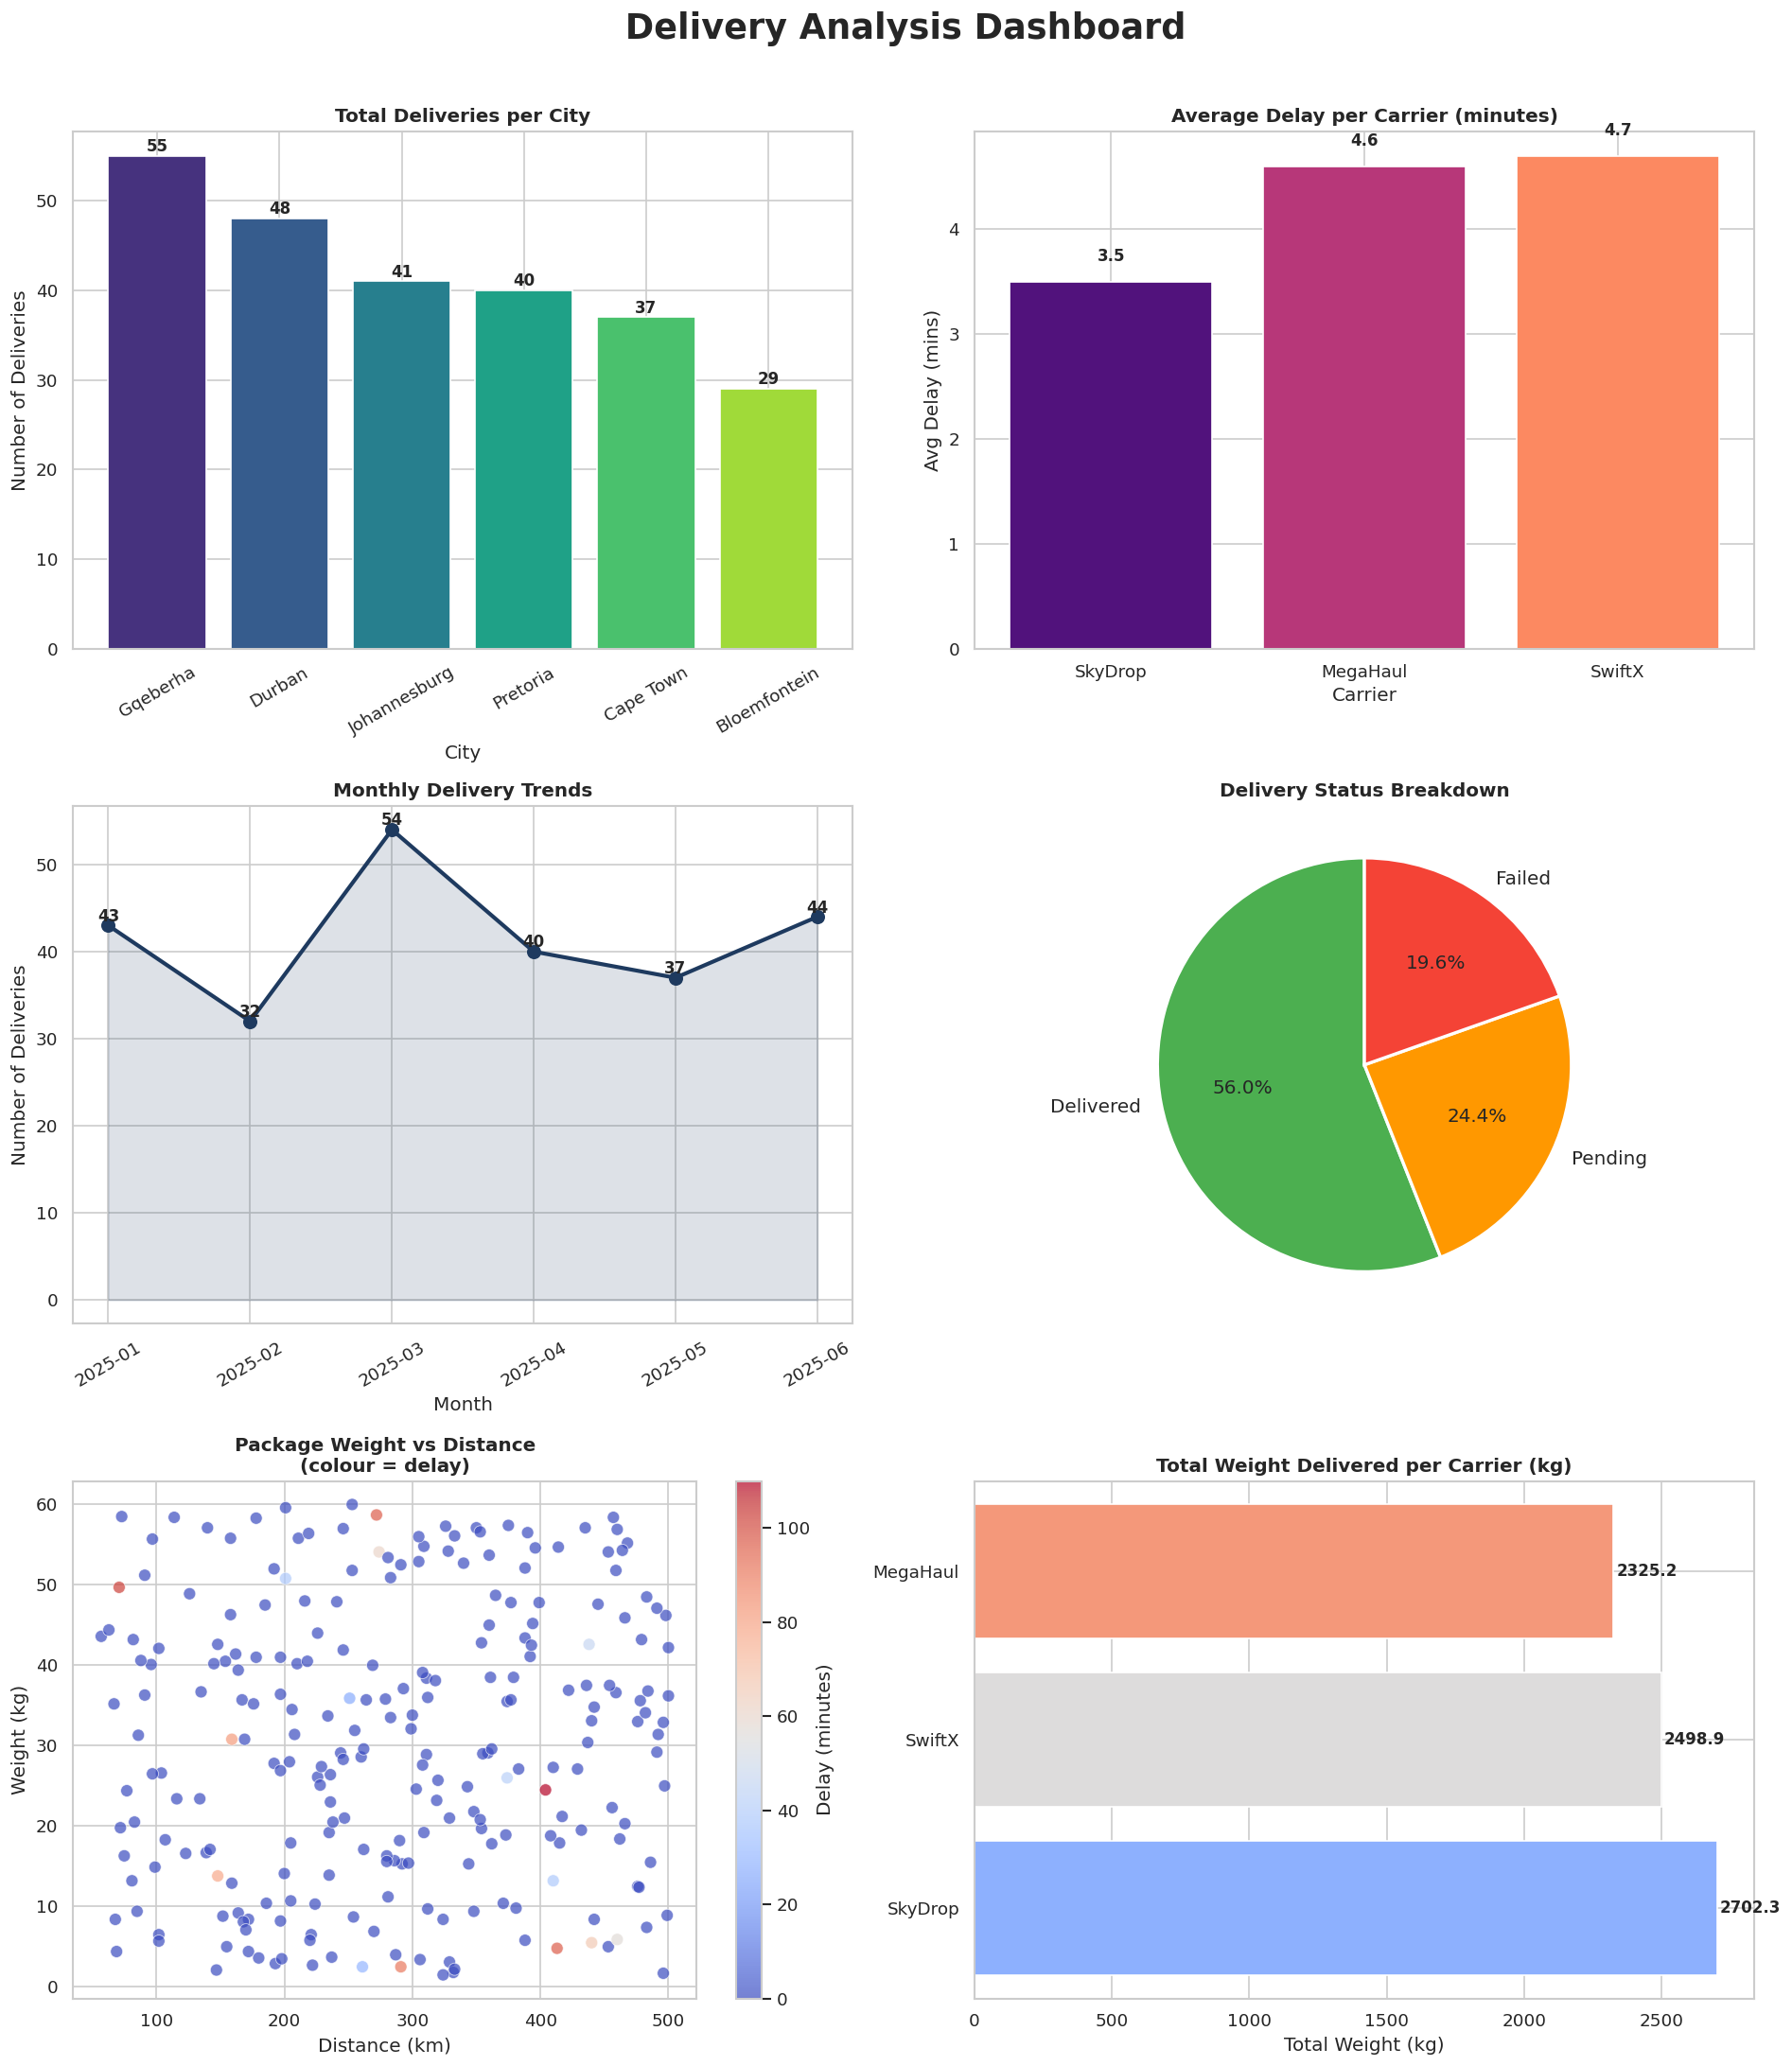

 Dashboard saved to delivery_dashboard.png


In [11]:
# ============================================================
#   CELL 6: Visualisations
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle(" Delivery Analysis Dashboard", fontsize=22, fontweight="bold", y=1.01)

# ── Chart 1: Deliveries per City ──
ax = axes[0][0]
colors = sns.color_palette("viridis", n_colors=len(deliveries_per_city))
bars = ax.bar(deliveries_per_city["city"], deliveries_per_city["total"], color=colors, edgecolor="white")
ax.set_title("Total Deliveries per City", fontweight="bold")
ax.set_xlabel("City")
ax.set_ylabel("Number of Deliveries")
ax.tick_params(axis="x", rotation=30)
for bar, val in zip(bars, deliveries_per_city["total"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            str(val), ha="center", fontsize=10, fontweight="bold")

# ── Chart 2: Average Delay per Carrier ──
ax = axes[0][1]
colors = sns.color_palette("magma", n_colors=len(carrier_performance))
bars = ax.bar(carrier_performance["carrier"], carrier_performance["avg_delay"], color=colors, edgecolor="white")
ax.set_title("Average Delay per Carrier (minutes)", fontweight="bold")
ax.set_xlabel("Carrier")
ax.set_ylabel("Avg Delay (mins)")
for bar, val in zip(bars, carrier_performance["avg_delay"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.2,
            str(val), ha="center", fontsize=10, fontweight="bold")

# ── Chart 3: Monthly Delivery Trends ──
ax = axes[1][0]
ax.plot(monthly_trends["month"], monthly_trends["deliveries"],
        marker="o", color="#1E3A5F", linewidth=2.5, markersize=8)
ax.fill_between(monthly_trends["month"], monthly_trends["deliveries"],
                alpha=0.15, color="#1E3A5F")
ax.set_title("Monthly Delivery Trends", fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Deliveries")
ax.tick_params(axis="x", rotation=30)
for i, val in enumerate(monthly_trends["deliveries"]):
    ax.text(i, val + 0.5, str(val), ha="center", fontsize=10, fontweight="bold")

# ── Chart 4: Delivery Status Breakdown ──
ax = axes[1][1]
colors = ["#4CAF50" if s == "Delivered" else "#FF9800" if s == "Pending" else "#F44336"
          for s in status_df["status"]]
ax.pie(status_df["total"], labels=status_df["status"], autopct="%1.1f%%",
       colors=colors, startangle=90, textprops={"fontsize": 12},
       wedgeprops=dict(edgecolor="white", linewidth=2))
ax.set_title("Delivery Status Breakdown", fontweight="bold")

# ── Chart 5: Weight vs Distance Scatter ──
ax = axes[2][0]
scatter = ax.scatter(
    df["distance_km"], df["weight_kg"],
    c=df["delay_minutes"], cmap="coolwarm",
    alpha=0.7, s=60, edgecolors="white", linewidth=0.5
)
plt.colorbar(scatter, ax=ax, label="Delay (minutes)")
ax.set_title("Package Weight vs Distance\n(colour = delay)", fontweight="bold")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Weight (kg)")

# ── Chart 6: Total Weight per Carrier ──
ax = axes[2][1]
colors = sns.color_palette("coolwarm", n_colors=len(weight_carrier))
bars = ax.barh(weight_carrier["carrier"], weight_carrier["total_weight"],
               color=colors, edgecolor="white")
ax.set_title("Total Weight Delivered per Carrier (kg)", fontweight="bold")
ax.set_xlabel("Total Weight (kg)")
for bar, val in zip(bars, weight_carrier["total_weight"]):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("delivery_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print(" Dashboard saved to delivery_dashboard.png")

In [15]:
# ============================================================
#   CELL 7: Key Insights
# ============================================================

print("=" * 55)
print("   KEY INSIGHTS")
print("=" * 55)

# Best & worst city
top_city    = deliveries_per_city.iloc[0]
bottom_city = deliveries_per_city.iloc[-1]

# Best & worst carrier
best_carrier  = carrier_performance.iloc[0]
worst_carrier = carrier_performance.iloc[-1]

# Delayed deliveries
delayed = conn.execute("SELECT COUNT(*) FROM deliveries WHERE delay_minutes > 0").fetchone()[0]
delayed_pct = round(delayed / 250 * 100, 1)

# On time
on_time_pct = round(100 - delayed_pct, 1)

# Busiest month
busiest_month = monthly_trends.loc[monthly_trends["deliveries"].idxmax()]

print(f"""
  Busiest City       : {top_city['city']} ({top_city['total']} deliveries)
  Quietest City      : {bottom_city['city']} ({bottom_city['total']} deliveries)

  Best Carrier       : {best_carrier['carrier']} (avg delay {best_carrier['avg_delay']} mins)
  Worst Carrier      : {worst_carrier['carrier']} (avg delay {worst_carrier['avg_delay']} mins)

  On-Time Rate        : {on_time_pct}%
  Delayed Rate       : {delayed_pct}% ({delayed} deliveries)

  Busiest Month      : {busiest_month['month']} ({busiest_month['deliveries']} deliveries)

  Heaviest Carrier   : {weight_carrier.iloc[0]['carrier']} ({weight_carrier.iloc[0]['total_weight']} kg total)
  Longest Avg Route  : {avg_distance.iloc[0]['city']} ({avg_distance.iloc[0]['avg_distance']} km avg)
""")
print("=" * 55)

   KEY INSIGHTS

  Busiest City       : Gqeberha (55 deliveries)
  Quietest City      : Bloemfontein (29 deliveries)

  Best Carrier       : SkyDrop (avg delay 3.5 mins)
  Worst Carrier      : SwiftX (avg delay 4.7 mins)

  On-Time Rate        : 93.6%
  Delayed Rate       : 6.4% (16 deliveries)

  Busiest Month      : 2025-03 (54 deliveries)

  Heaviest Carrier   : SkyDrop (2702.3 kg total)
  Longest Avg Route  : Cape Town (311.6 km avg)

